# Pipeline vs Baseline Experiment

In [1]:
import sys
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

BASELINE_DIR = REPO_ROOT / "baseline"
if str(BASELINE_DIR) not in sys.path:
    sys.path.insert(0, str(BASELINE_DIR))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = REPO_ROOT / "database" / "training_data.json"
EXPERIMENT_DIR = REPO_ROOT / "experiments"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"CUDA available: {torch.cuda.is_available()}")

Repo root: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline
Data path: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/database/training_data.json
CUDA available: True


In [2]:
import logging
from datetime import datetime

from logger import configure_logging

TRACE_LOG_PATH = EXPERIMENT_DIR / f"experimentation_pipeline_vs_baseline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
configure_logging(
    level="INFO",
    log_file=str(TRACE_LOG_PATH),
    enable_console=True,
    enable_file=True,
)

exp_logger = logging.getLogger("experimentation_pipeline_vs_baseline")
exp_logger.info("Trace logging initialized")
print(f"Trace log file: {TRACE_LOG_PATH}")

2026-03-24 11:59:37,436 - experimentation_pipeline_vs_baseline - INFO - Trace logging initialized
Trace log file: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/experimentation_pipeline_vs_baseline_20260324_115937.log


In [3]:
TARGET = {
    "dbaasp_id": "DBAASPS_373",
    "sequence": "KLFKRWKHLFR",
    "length": 11,
    "smiles": "CC(C)C[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)CCCCN)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCCN=C(N)N)C(=O)O",
    "ph": None,
    "molecular_weight": 1558.9480000000003,
    "logp": -0.992100000000006,
    "net_charge": 5.0,
    "isoelectric_point": 12.18,
    "hydrophobicity": 1.05,
    "cathionicity": 6,
    "target_groups": ["Gram+"],
    "complexity": "Monomer"
}

SHARED_MAX_LEN = 14
SHARED_BATCH_SIZE = 32
SHARED_EPOCHS = 100
SHARED_LATENT_DIM = 32

# Tuned pipeline hyperparameters (from pipeline_experimentations reference setup).
PIPELINE_LATENT_DIM = 64
PIPELINE_HIDDEN_DIM = 512
PIPELINE_EPOCHS = 120
PIPELINE_BATCH_SIZE = 64
PIPELINE_LR = 0.05
PIPELINE_KL_ANNEAL_EPOCHS = 40

NB_ITERATIONS = 50
NB_PEPTIDES = 300
TOP_K = 10
BASELINE_NUM_SAMPLES = 10

print(TARGET)
print(
    f"Pipeline tuned config -> latent={PIPELINE_LATENT_DIM}, hidden={PIPELINE_HIDDEN_DIM}, "
    f"epochs={PIPELINE_EPOCHS}, batch={PIPELINE_BATCH_SIZE}, lr={PIPELINE_LR}, kl_anneal={PIPELINE_KL_ANNEAL_EPOCHS}"
)

{'dbaasp_id': 'DBAASPS_373', 'sequence': 'KLFKRWKHLFR', 'length': 11, 'smiles': 'CC(C)C[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)CCCCN)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCCN=C(N)N)C(=O)O', 'ph': None, 'molecular_weight': 1558.9480000000003, 'logp': -0.992100000000006, 'net_charge': 5.0, 'isoelectric_point': 12.18, 'hydrophobicity': 1.05, 'cathionicity': 6, 'target_groups': ['Gram+'], 'complexity': 'Monomer'}
Pipeline tuned config -> latent=64, hidden=512, epochs=120, batch=64, lr=0.05, kl_anneal=40


In [4]:
from training import train_model
from inference import generate_peptides

baseline_model_path = EXPERIMENT_DIR / "baseline_cvae_model.pth"
baseline_scaler_path = EXPERIMENT_DIR / "baseline_scaler.pkl"

baseline_model, _ = train_model(
    dataset_file=str(DATA_PATH),
    scaler_path=str(baseline_scaler_path),
    batch_size=SHARED_BATCH_SIZE,
    max_len=SHARED_MAX_LEN,
    epochs=SHARED_EPOCHS,
    latent_dim=SHARED_LATENT_DIM,
    model_path=str(baseline_model_path),
)

with open(baseline_scaler_path, "rb") as f:
    baseline_scaler = pickle.load(f)

baseline_target = [
    TARGET["length"],
    7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
    TARGET["molecular_weight"],
    TARGET["logp"],
    TARGET["net_charge"],
    TARGET["isoelectric_point"],
    TARGET["hydrophobicity"],
    TARGET["cathionicity"],
]

baseline_sequences = generate_peptides(
    model=baseline_model,
    scaler=baseline_scaler,
    num_samples=BASELINE_NUM_SAMPLES,
    properties=baseline_target,
    temperature=0.9,
    top_k=5,
)

Using device: cuda
Scaler saved to /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/baseline_scaler.pkl
Epoch [1/100] | Beta: 0.00 | Train Loss: 21.4799 | Train Recon: 21.4799 | Train KL: 66.7116 | Val Loss: 18.3806 | Val Recon: 18.3806 | Val KL: 108.8033
Epoch [5/100] | Beta: 0.08 | Train Loss: 13.9652 | Train Recon: 12.3938 | Train KL: 19.6430 | Val Loss: 13.4713 | Val Recon: 11.9304 | Val KL: 19.2605
Epoch [10/100] | Beta: 0.18 | Train Loss: 11.5829 | Train Recon: 8.9925 | Train KL: 14.3912 | Val Loss: 11.8423 | Val Recon: 9.3397 | Val KL: 13.9030
Epoch [15/100] | Beta: 0.28 | Train Loss: 10.7538 | Train Recon: 7.5165 | Train KL: 11.5619 | Val Loss: 11.6593 | Val Recon: 8.5647 | Val KL: 11.0521
Epoch [20/100] | Beta: 0.38 | Train Loss: 10.7060 | Train Recon: 7.1009 | Train KL: 9.4871 | Val Loss: 11.9754 | Val Recon: 8.4172 | Val KL: 9.3638
Epoch [25/100] | Beta: 0.48 | Train Loss: 10.7938 | Train Recon: 6.9396 | Train KL: 8.0294 | Val Loss: 12.0935 | Val Recon

In [5]:
from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator

AA = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_IDX = {aa: i for i, aa in enumerate(AA)}
PAD_IDX = 20
VOCAB_SIZE = 21


def encode_one_hot_with_pad(sequences, max_len):
    x = torch.zeros(len(sequences), max_len * VOCAB_SIZE, dtype=torch.float32)
    for i, seq in enumerate(sequences):
        for pos in range(max_len):
            x[i, pos * VOCAB_SIZE + PAD_IDX] = 1.0
        for pos, aa in enumerate(seq[:max_len]):
            if aa in AA_TO_IDX:
                x[i, pos * VOCAB_SIZE + PAD_IDX] = 0.0
                x[i, pos * VOCAB_SIZE + AA_TO_IDX[aa]] = 1.0
    return x


def build_condition_tensor(dataframe, model):
    cond = torch.zeros(len(dataframe), model.condition_dim, dtype=torch.float32)
    cond[:, 0] = torch.tensor(dataframe["length"].values, dtype=torch.float32)
    cond[:, 1] = torch.tensor(dataframe["molecular_weight"].values, dtype=torch.float32)
    cond[:, 2] = torch.tensor(dataframe["net_charge"].values, dtype=torch.float32)
    cond[:, 3] = torch.tensor(dataframe["isoelectric_point"].values, dtype=torch.float32)
    cond[:, 4] = torch.tensor(dataframe["hydrophobicity"].values, dtype=torch.float32)
    cond[:, 5] = torch.tensor(dataframe["cathionicity"].values, dtype=torch.float32)
    cond[:, 6] = 0.5
    cond[:, 7] = torch.tensor(dataframe["logp"].values, dtype=torch.float32)
    cond[:, 8] = 0.0
    cond[:, 9] = 5.0
    cond[:, 10] = 5.0
    cond[:, 11] = 100.0
    return cond


loader = JSONDataLoader()
loader.load_data(
    source=str(DATA_PATH),
    columns=[
        "sequence",
        "length",
        "ph",
        "molecular_weight",
        "logp",
        "net_charge",
        "isoelectric_point",
        "hydrophobicity",
        "cathionicity",
    ],
    fillna_defaults={
        "length": 10,
        "ph": 7.0,
        "molecular_weight": 1500.0,
        "logp": 0.0,
        "net_charge": 0.0,
        "isoelectric_point": 7.0,
        "hydrophobicity": 0.0,
        "cathionicity": 0.0,
    },
    normalize_sequence=True,
    sequence_column="sequence",
    keep_standard_amino_acids_only=True,
)

pipeline_df = loader.get_data().copy()

pipeline_cvae = CVAEGenerator(
    max_len=SHARED_MAX_LEN,
    latent_dim=PIPELINE_LATENT_DIM,
    hidden_dim=PIPELINE_HIDDEN_DIM,
    condition_dim=32,
)

pipeline_model_path = EXPERIMENT_DIR / (
    f"pipeline_cvae_model_lat{PIPELINE_LATENT_DIM}_hid{PIPELINE_HIDDEN_DIM}_ep{PIPELINE_EPOCHS}_bs{PIPELINE_BATCH_SIZE}.pth"
)

x = encode_one_hot_with_pad(pipeline_df["sequence"].tolist(), max_len=SHARED_MAX_LEN)
conditions = build_condition_tensor(pipeline_df, pipeline_cvae)
lengths = torch.tensor(pipeline_df["length"].astype(int).values, dtype=torch.long)

x = x.to(pipeline_cvae.device)
conditions = conditions.to(pipeline_cvae.device)
lengths = lengths.to(pipeline_cvae.device)

if pipeline_model_path.exists():
    pipeline_cvae.load_model(str(pipeline_model_path))
else:
    pipeline_cvae.train_model(
        data=x,
        conditions=conditions,
        lengths=lengths,
        epochs=PIPELINE_EPOCHS,
        batch_size=PIPELINE_BATCH_SIZE,
        lr=PIPELINE_LR,
        kl_anneal_epochs=PIPELINE_KL_ANNEAL_EPOCHS,
    )
    pipeline_cvae.save_model(str(pipeline_model_path))

print(f"Using pipeline model path: {pipeline_model_path.name}")

2026-03-24 12:00:25,673 - peptide_pipeline.dataloader - INFO - DataLoader initialized.
2026-03-24 12:00:25,714 - peptide_pipeline.dataloader - INFO - Data loaded successfully from /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/database/training_data.json. Total records: 4410
2026-03-24 12:00:25,714 - peptide_pipeline.dataloader - INFO - Data retrieval successful.
Using pipeline model path: pipeline_cvae_model_lat64_hid512_ep120_bs64.pth


In [6]:
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator
from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2
from peptide_pipeline.biologist.base import BaseBiologist


class FallbackBiologist(BaseBiologist):
    def __init__(self, reference_peptide):
        self.reference = reference_peptide

    def score_peptides(self, peptides):
        scores = []
        ref_set = set(self.reference)
        for p in peptides:
            common = len(ref_set.intersection(set(p)))
            scores.append(common / max(len(set(self.reference)), 1))
        return scores


chemist_config = ChemistConfig(
    ph=7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
    length=RangeTarget(min=8.0, max=14.0, target=float(TARGET["length"]), weight=1.0),
    molecular_weight=RangeTarget(min=1200.0, max=2000.0, target=float(TARGET["molecular_weight"]), weight=1.0),
    logp=RangeTarget(min=-3.0, max=3.0, target=float(TARGET["logp"]), weight=1.0),
    net_charge=RangeTarget(min=2.0, max=8.0, target=float(TARGET["net_charge"]), weight=1.0),
    isoelectric_point=RangeTarget(min=9.0, max=14.0, target=float(TARGET["isoelectric_point"]), weight=1.0),
    hydrophobicity=RangeTarget(min=-2.0, max=3.0, target=float(TARGET["hydrophobicity"]), weight=1.0),
)

chemist = ChemistAgent(config=chemist_config)

try:
    biologist = ESMBiologistGlobalL2(
        reference_peptide=TARGET["sequence"],
        batch_size=16,
        score_temperature=50.0,
    )
except Exception as e:
    print(f"Falling back to lightweight biologist: {e}")
    biologist = FallbackBiologist(reference_peptide=TARGET["sequence"])

orchestrator = Orchestrator(generator=pipeline_cvae, chemist=chemist, biologist=biologist)
pipeline_results = orchestrator.run(
    nb_iterations=NB_ITERATIONS,
    nb_peptides=NB_PEPTIDES,
    top_k=TOP_K,
    exploration_rate=0.15,
    initial_peptide=TARGET["sequence"],
    final_target={
        "length": TARGET["length"],
        "molecular_weight": TARGET["molecular_weight"],
        "logp": TARGET["logp"],
        "net_charge": TARGET["net_charge"],
        "isoelectric_point": TARGET["isoelectric_point"],
        "hydrophobicity": TARGET["hydrophobicity"],
        "cathionicity": TARGET["cathionicity"],
    },
)

2026-03-24 12:00:26,157 - rdkit - INFO - Enabling RDKit 2025.09.6 jupyter extensions


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-03-24 12:00:27,702 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 12:00:27,720 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/config.json "HTTP/1.1 200 OK"
2026-03-24 12:00:27,845 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 12:00:27,862 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-24 12:00:27,982 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/esm2_t12_35M_UR50D/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-24 12:0

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1291.22it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2026-03-24 12:00:28,668 - peptide_pipeline.orchestrator - INFO - Pipeline start: 50 iterations, 300 peptides/iteration, exploration_rate=0.15, top_k=10
2026-03-24 12:00:28,669 - peptide_pipeline.orchestrator - INFO - Iteration 1: initial_peptide is provided ('KLFKRWKHLFR') but generation is driven by final_target constraints only.
2026-03-24 12:00:29,029 - peptide_pipeline.orchestrator - INFO - Iteration 1: mode=target_only, generated=300, in_limits=1, off_limits=299, best_combined=0.8315, global_unique=1


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")


2026-03-24 12:00:29,380 - peptide_pipeline.orchestrator - INFO - Iteration 2: mode=exploitation_top, generated=300, in_limits=3, off_limits=297, best_combined=0.8222, global_unique=4
2026-03-24 12:00:29,735 - peptide_pipeline.orchestrator - INFO - Iteration 3: mode=exploration_random, generated=300, in_limits=7, off_limits=293, best_combined=0.8549, global_unique=11
2026-03-24 12:00:30,086 - peptide_pipeline.orchestrator - INFO - Iteration 4: mode=exploitation_top, generated=300, in_limits=4, off_limits=296, best_combined=0.8293, global_unique=15
2026-03-24 12:00:30,438 - peptide_pipeline.orchestrator - INFO - Iteration 5: mode=exploitation_top, generated=300, in_limits=7, off_limits=293, best_combined=0.8124, global_unique=22
2026-03-24 12:00:30,786 - peptide_pipeline.orchestrator - INFO - Iteration 6: mode=exploitation_top, generated=300, in_limits=4, off_limits=296, best_combined=0.7893, global_unique=26
2026-03-24 12:00:31,139 - peptide_pipeline.orchestrator - INFO - Iteration 7: m

In [7]:
import csv

pipeline_display = []
for row in pipeline_results:
    item = {
        "sequence": row.get("peptide", ""),
        "score": row.get("score"),
        "chemist_score": row.get("chemist_score"),
        "biologist_score": row.get("biologist_score"),
        "length": row.get("properties", {}).get("length"),
        "molecular_weight": row.get("properties", {}).get("molecular_weight"),
        "net_charge": row.get("properties", {}).get("net_charge"),
        "isoelectric_point": row.get("properties", {}).get("isoelectric_point"),
        "hydrophobicity": row.get("properties", {}).get("hydrophobicity"),
        "logp": row.get("properties", {}).get("logp"),
        "in_limits": row.get("in_limits", False),
    }
    pipeline_display.append(item)

pipeline_display_df = pd.DataFrame(pipeline_display)
if not pipeline_display_df.empty:
    pipeline_display_df = pipeline_display_df.sort_values(by=["in_limits", "score"], ascending=[False, False]).reset_index(drop=True)
    for col in ["score", "chemist_score", "biologist_score", "molecular_weight", "net_charge", "isoelectric_point", "hydrophobicity", "logp"]:
        if col in pipeline_display_df.columns:
            pipeline_display_df[col] = pipeline_display_df[col].astype(float).round(3)

baseline_clean = [seq for seq in baseline_sequences if isinstance(seq, str) and seq]
baseline_df = pd.DataFrame({
    "rank": list(range(1, len(baseline_clean) + 1)),
    "sequence": baseline_clean,
})

target_df = pd.DataFrame([TARGET])
combined_csv_path = EXPERIMENT_DIR / "pipeline_vs_baseline_results.csv"

target_cols = list(target_df.columns)
pipeline_cols = [
    "sequence",
    "score",
    "chemist_score",
    "biologist_score",
    "in_limits",
    "length",
    "molecular_weight",
    "net_charge",
    "isoelectric_point",
    "hydrophobicity",
    "logp",
]
baseline_cols = ["rank", "sequence"]

with open(combined_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow(["TARGET"])
    writer.writerow(target_cols)
    writer.writerow([TARGET.get(col, "") for col in target_cols])
    writer.writerow([])

    writer.writerow(["PIPELINE_RESULTS"])
    writer.writerow(pipeline_cols)
    if not pipeline_display_df.empty:
        for _, row in pipeline_display_df.iterrows():
            writer.writerow([row.get(col, "") for col in pipeline_cols])
    writer.writerow([])

    writer.writerow(["BASELINE_RESULTS"])
    writer.writerow(baseline_cols)
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            writer.writerow([row.get(col, "") for col in baseline_cols])

In [8]:
print("Pipeline results:")
if pipeline_display_df.empty:
    print("No peptide returned by the pipeline.")
else:
    print(f"Total peptides: {len(pipeline_display_df)}")
    display(pipeline_display_df)

print("Basline results:")
if baseline_df.empty:
    print("No sequence returned by the baseline.")
else:
    print(f"Total sequences: {len(baseline_df)}")
    for i, seq in enumerate(baseline_df["sequence"].tolist(), start=1):
        print(f"{i:02d}. {seq}")

Pipeline results:
Total peptides: 10


,sequence,score,chemist_score,biologist_score,length,molecular_weight,net_charge,isoelectric_point,hydrophobicity,logp,in_limits
0,FKWRKMILRRA,0.869,0.846,0.893,11,1504.906,4.997,12.814,-0.673,-1.874,True
1,LCRRHKFRVWF,0.858,0.843,0.872,11,1547.890,4.027,12.223,-0.491,-2.028,True
2,FKRFKCTIRIW,0.855,0.836,0.874,11,1497.868,3.935,11.652,-0.118,-1.357,True
3,KKMVKNVLRFF,0.851,0.819,0.883,11,1409.799,3.997,11.925,-0.000,-1.631,True
4,KLMKVHWRHPK,0.849,0.803,0.895,11,1459.822,4.179,11.925,-1.382,-1.486,True
5,IAKIKCFKLKR,0.848,0.816,0.879,11,1347.772,4.935,11.249,-0.018,-1.644,True
6,ARRWDKWFRVF,0.847,0.803,0.892,11,1566.831,2.998,12.223,-1.009,-1.751,True
7,AIKVYIPRRKW,0.846,0.818,0.874,11,1429.775,3.997,11.677,-0.509,-1.023,True
8,YFIRFIRGMHR,0.844,0.803,0.886,11,1495.811,3.088,12.204,-0.173,-2.088,True
9,KKRINVKIIMF,0.843,0.830,0.855,11,1389.809,3.997,11.925,0.245,-1.438,True


Basline results:
Total sequences: 10
01. KWFKKFFHKKW
02. KRWVKWIKKFR
03. RKFKKFFKKFT
04. KRIWKRIWKHI
05. RWRKLFKWLK
06. FRWWKRIKKFL
07. RWKIFKKIWRH
08. KRIVQRIKKFL
09. KRIWKRIWKHL
10. KRIWWIRWKIR


## Target-Length Comparison

Compare three methods across target lengths 4 to 11:
- baseline
- pipeline_low_iter (3 iterations)
- pipeline_high_iter (10 iterations)

Reported per method and length:
- avg_combined
- generated / unique / duplicate counts
- duplicate_rate

In [16]:
from contextlib import contextmanager
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import torch

from baseline.model import PeptideCVAE
from baseline.data_handler import VOCAB
from baseline.inference import generate_peptides

from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator


LENGTH_TEST_CONFIG = {
    "lengths": list(range(4, 12)),
    "repeats": 5,
    "peptides_per_iter": 48,
    "top_k": 10,
    "pipeline_modes": [
        ("pipeline_one_iter", 1),
        ("pipeline_three_iter", 3),
        ("pipeline_ten_iter", 10),
    ],
    "baseline_top_k": 5,
    "temperature": 0.9,
    "exploration_rate": 0.15,
}


def _identity(seq, ref):
    if not seq or not ref:
        return 0.0
    n = min(len(seq), len(ref))
    return sum(1 for a, b in zip(seq[:n], ref[:n]) if a == b) / max(len(ref), 1)


class _FallbackBiologist:
    def __init__(self, reference):
        self.reference = reference

    def score_peptides(self, peptides):
        return [_identity(p, self.reference) for p in peptides]


@contextmanager
def _cpu_only_cuda_flag():
    original = torch.cuda.is_available
    torch.cuda.is_available = lambda: False
    try:
        yield
    finally:
        torch.cuda.is_available = original


def _load_baseline_on_cpu():
    model_path = Path(globals().get("baseline_model_path", EXPERIMENT_DIR / "baseline_cvae_model.pth"))
    scaler_path = Path(globals().get("baseline_scaler_path", EXPERIMENT_DIR / "baseline_scaler.pkl"))

    if not model_path.exists() or not scaler_path.exists():
        raise RuntimeError(
            f"Baseline artifacts missing. Expected model={model_path} and scaler={scaler_path}. Run baseline setup cells first."
        )

    model = PeptideCVAE(
        vocab_size=len(VOCAB),
        condition_dim=8,
        max_seq_len=SHARED_MAX_LEN + 2,
        latent_dim=SHARED_LATENT_DIM,
    )
    state = torch.load(model_path, map_location=torch.device("cpu"))
    model.load_state_dict(state)
    model = model.to(torch.device("cpu"))

    with open(scaler_path, "rb") as f:
        scaler = pickle.load(f)

    return model, scaler


def _load_pipeline_on_cpu():
    model_path = EXPERIMENT_DIR / (
        f"pipeline_cvae_model_lat{PIPELINE_LATENT_DIM}_hid{PIPELINE_HIDDEN_DIM}_ep{PIPELINE_EPOCHS}_bs{PIPELINE_BATCH_SIZE}.pth"
    )
    if not model_path.exists():
        raise RuntimeError(
            f"Pipeline model not found at {model_path}. Run pipeline setup cells first."
        )

    with _cpu_only_cuda_flag():
        model = CVAEGenerator(
            max_len=SHARED_MAX_LEN,
            latent_dim=PIPELINE_LATENT_DIM,
            hidden_dim=PIPELINE_HIDDEN_DIM,
            condition_dim=32,
        )
    model.load_model(str(model_path))
    model.to(torch.device("cpu"))
    model.device = torch.device("cpu")
    return model


def _get_biologist(reference_sequence):
    try:
        from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2

        return ESMBiologistGlobalL2(reference_peptide=reference_sequence, batch_size=16, score_temperature=50.0)
    except Exception as e:
        print(f"Using fallback biologist: {e}")
        return _FallbackBiologist(reference_sequence)


def _build_target(length_value):
    t = dict(TARGET)
    t["length"] = int(length_value)
    return {
        "sequence": str(t["sequence"]),
        "length": int(t["length"]),
        "ph": 7.0 if pd.isna(t.get("ph", None)) else float(t["ph"]),
        "molecular_weight": float(t["molecular_weight"]),
        "logp": float(t["logp"]),
        "net_charge": float(t["net_charge"]),
        "isoelectric_point": float(t["isoelectric_point"]),
        "hydrophobicity": float(t["hydrophobicity"]),
        "cathionicity": float(t["cathionicity"]),
    }


def _build_chemist(target):
    def around(value, margin, lo=None, hi=None):
        x = float(value)
        mn = x - float(margin)
        mx = x + float(margin)
        if lo is not None:
            mn = max(mn, float(lo))
        if hi is not None:
            mx = min(mx, float(hi))
        return float(min(mn, x)), float(max(mx, x))

    len_min, len_max = around(target["length"], 2.0, 2.0, 14.0)
    mw_min, mw_max = around(target["molecular_weight"], 500.0, 100.0, 3000.0)
    logp_min, logp_max = around(target["logp"], 2.5, -8.0, 8.0)
    chg_min, chg_max = around(target["net_charge"], 4.0, -8.0, 12.0)
    pI_min, pI_max = around(target["isoelectric_point"], 3.0, 2.0, 14.0)
    hyd_min, hyd_max = around(target["hydrophobicity"], 2.5, -8.0, 8.0)

    cfg = ChemistConfig(
        ph=float(target["ph"]),
        length=RangeTarget(min=len_min, max=len_max, target=float(target["length"]), weight=1.0),
        molecular_weight=RangeTarget(min=mw_min, max=mw_max, target=float(target["molecular_weight"]), weight=1.0),
        logp=RangeTarget(min=logp_min, max=logp_max, target=float(target["logp"]), weight=1.0),
        net_charge=RangeTarget(min=chg_min, max=chg_max, target=float(target["net_charge"]), weight=1.0),
        isoelectric_point=RangeTarget(min=pI_min, max=pI_max, target=float(target["isoelectric_point"]), weight=1.0),
        hydrophobicity=RangeTarget(min=hyd_min, max=hyd_max, target=float(target["hydrophobicity"]), weight=1.0),
    )
    return ChemistAgent(config=cfg)


def _score_baseline(sequences, chemist, biologist):
    clean = [s for s in sequences if isinstance(s, str) and s]
    if not clean:
        return 0.0

    chem_rows = chemist.evaluate_peptides(clean)
    valid = [r for r in chem_rows if isinstance(r, dict) and r.get("sequence")]
    if not valid:
        return 0.0

    bio_scores = biologist.score_peptides([r["sequence"] for r in valid])
    combined = [0.5 * (float(r.get("score", 0.0)) + float(b)) for r, b in zip(valid, bio_scores)]
    return float(np.mean(combined)) if combined else 0.0


baseline_model_cpu, baseline_scaler_cpu = _load_baseline_on_cpu()
pipeline_model_cpu = _load_pipeline_on_cpu()


all_rows = []
mode_names = [name for name, _ in LENGTH_TEST_CONFIG["pipeline_modes"]]
max_iters = max(iters for _, iters in LENGTH_TEST_CONFIG["pipeline_modes"] if iters is not None)
baseline_budget = int(max_iters * LENGTH_TEST_CONFIG["peptides_per_iter"])

for target_length in LENGTH_TEST_CONFIG["lengths"]:
    target_cfg = _build_target(target_length)
    biologist = _get_biologist(target_cfg["sequence"])

    baseline_properties = [
        target_cfg["length"],
        target_cfg["ph"],
        target_cfg["molecular_weight"],
        target_cfg["logp"],
        target_cfg["net_charge"],
        target_cfg["isoelectric_point"],
        target_cfg["hydrophobicity"],
        target_cfg["cathionicity"],
    ]

    for run_idx in range(1, LENGTH_TEST_CONFIG["repeats"] + 1):
        seed = SEED + 70000 + 100 * int(target_length) + run_idx
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        chemist = _build_chemist(target_cfg)

        with _cpu_only_cuda_flag():
            baseline_peptides = generate_peptides(
                model=baseline_model_cpu,
                scaler=baseline_scaler_cpu,
                num_samples=baseline_budget,
                properties=baseline_properties,
                temperature=LENGTH_TEST_CONFIG["temperature"],
                top_k=LENGTH_TEST_CONFIG["baseline_top_k"],
            )

        baseline_clean = [p for p in baseline_peptides if isinstance(p, str) and p]
        baseline_unique = len(set(baseline_clean))
        baseline_dup = max(0, len(baseline_clean) - baseline_unique)
        baseline_avg = _score_baseline(baseline_clean, chemist, biologist)

        all_rows.append(
            {
                "target_length": int(target_length),
                "run": run_idx,
                "method": "baseline",
                "iterations": None,
                "requested_budget": baseline_budget,
                "avg_combined": float(baseline_avg),
                "generated_count": int(len(baseline_clean)),
                "unique_count": int(baseline_unique),
                "duplicate_count": int(baseline_dup),
                "duplicate_rate": float(baseline_dup / max(len(baseline_clean), 1)),
                "topk_generated_count": int(len(baseline_clean)),
                "topk_unique_count": int(baseline_unique),
                "topk_duplicate_count": int(baseline_dup),
                "topk_duplicate_rate": float(baseline_dup / max(len(baseline_clean), 1)),
                "target_sequence": target_cfg["sequence"],
            }
        )

        constraints = {
            "size": float(target_cfg["length"]),
            "molecular_weight": float(target_cfg["molecular_weight"]),
            "net_charge_pH5_5": float(target_cfg["net_charge"]),
            "isoelectric_point": float(target_cfg["isoelectric_point"]),
            "hydrophobicity": float(target_cfg["hydrophobicity"]),
            "cathionicity": float(target_cfg["cathionicity"]),
            "logp": float(target_cfg["logp"]),
        }

        for method_name, iter_count in LENGTH_TEST_CONFIG["pipeline_modes"]:
            requested_budget = int(iter_count * LENGTH_TEST_CONFIG["peptides_per_iter"])

            orchestrator = Orchestrator(
                generator=pipeline_model_cpu,
                chemist=chemist,
                biologist=biologist,
            )

            pipeline_topk_sequences = []
            pipeline_avg = 0.0
            try:
                pipeline_rows = orchestrator.run(
                    nb_iterations=iter_count,
                    nb_peptides=LENGTH_TEST_CONFIG["peptides_per_iter"],
                    top_k=LENGTH_TEST_CONFIG["top_k"],
                    exploration_rate=LENGTH_TEST_CONFIG["exploration_rate"],
                    initial_peptide=target_cfg["sequence"],
                    final_target={
                        "length": target_cfg["length"],
                        "molecular_weight": target_cfg["molecular_weight"],
                        "logp": target_cfg["logp"],
                        "net_charge": target_cfg["net_charge"],
                        "isoelectric_point": target_cfg["isoelectric_point"],
                        "hydrophobicity": target_cfg["hydrophobicity"],
                        "cathionicity": target_cfg["cathionicity"],
                    },
                )
                score_vals = [
                    float(r.get("combined_score", r.get("score", 0.0)))
                    for r in pipeline_rows
                    if isinstance(r, dict)
                ]
                pipeline_avg = float(np.mean(score_vals)) if score_vals else 0.0
                pipeline_topk_sequences = [
                    str(r.get("peptide", ""))
                    for r in pipeline_rows
                    if isinstance(r, dict) and isinstance(r.get("peptide", ""), str) and r.get("peptide", "")
                ]
            except Exception as e:
                print(f"Pipeline orchestrator fallback ({method_name}, L={target_length}, run={run_idx}): {e}")
                try:
                    fallback_peptides = pipeline_model_cpu.generate_peptides(
                        count=requested_budget,
                        constraints=constraints,
                    )
                except Exception:
                    fallback_peptides = pipeline_model_cpu.generate_peptides(
                        count=requested_budget,
                        constraints=None,
                    )
                pipeline_topk_sequences = [p for p in fallback_peptides if isinstance(p, str) and p]
                pipeline_avg = _score_baseline(pipeline_topk_sequences, chemist, biologist)

            topk_unique = len(set(pipeline_topk_sequences))
            topk_dup = max(0, len(pipeline_topk_sequences) - topk_unique)

            try:
                budget_peptides = pipeline_model_cpu.generate_peptides(
                    count=requested_budget,
                    constraints=constraints,
                )
            except Exception:
                budget_peptides = pipeline_model_cpu.generate_peptides(
                    count=requested_budget,
                    constraints=None,
                )

            budget_clean = [p for p in budget_peptides if isinstance(p, str) and p]
            budget_unique = len(set(budget_clean))
            budget_dup = max(0, len(budget_clean) - budget_unique)

            all_rows.append(
                {
                    "target_length": int(target_length),
                    "run": run_idx,
                    "method": method_name,
                    "iterations": int(iter_count),
                    "requested_budget": int(requested_budget),
                    "avg_combined": float(pipeline_avg),
                    "generated_count": int(len(budget_clean)),
                    "unique_count": int(budget_unique),
                    "duplicate_count": int(budget_dup),
                    "duplicate_rate": float(budget_dup / max(len(budget_clean), 1)),
                    "topk_generated_count": int(len(pipeline_topk_sequences)),
                    "topk_unique_count": int(topk_unique),
                    "topk_duplicate_count": int(topk_dup),
                    "topk_duplicate_rate": float(topk_dup / max(len(pipeline_topk_sequences), 1)),
                    "target_sequence": target_cfg["sequence"],
                }
            )

hardness_raw_df = pd.DataFrame(all_rows)

if hardness_raw_df.empty:
    print("No results produced for target-length comparison.")
else:
    display(hardness_raw_df)

    hardness_summary_df = (
        hardness_raw_df.groupby(["target_length", "method"], as_index=False)
        .agg(
            requested_budget_mean=("requested_budget", "mean"),
            avg_score=("avg_combined", "mean"),
            std_score=("avg_combined", "std"),
        )
        .sort_values(["target_length", "method"], ascending=[False, True])
        .reset_index(drop=True)
    )

    hardness_variety_summary_df = (
        hardness_raw_df.groupby(["target_length", "method"], as_index=False)
        .agg(
            requested_budget_mean=("requested_budget", "mean"),
            generated_mean=("generated_count", "mean"),
            unique_mean=("unique_count", "mean"),
            duplicate_mean=("duplicate_count", "mean"),
            duplicate_rate_mean=("duplicate_rate", "mean"),
            duplicate_rate_std=("duplicate_rate", "std"),
            topk_generated_mean=("topk_generated_count", "mean"),
            topk_unique_mean=("topk_unique_count", "mean"),
            topk_duplicate_mean=("topk_duplicate_count", "mean"),
            topk_duplicate_rate_mean=("topk_duplicate_rate", "mean"),
            topk_duplicate_rate_std=("topk_duplicate_rate", "std"),
        )
        .sort_values(["target_length", "method"], ascending=[False, True])
        .reset_index(drop=True)
    )

    display(hardness_summary_df)
    display(hardness_variety_summary_df)

2026-03-24 12:06:17,652 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 12:06:17,671 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/config.json "HTTP/1.1 200 OK"
2026-03-24 12:06:17,792 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 12:06:17,818 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-24 12:06:17,938 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/esm2_t12_35M_UR50D/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-24 12:0

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 505.32it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cpu
Model loaded successfully.

Target Properties:
- Length: 4.0
- pH: 7.0
- Molecular Weight: 1558.9480000000003
- LogP: -0.992100000000006
- Net Charge: 5.0
- Isoelectric Point: 12.18
- Hydrophobicity: 1.05
- Cathionicity: 6.0

--- Generating 480 novel peptide(s) ---
Sample 1: KKKRK
Sample 2: KKKKK
Sample 3: KKKRK
Sample 4: KKKRK
Sample 5: KKKRK
Sample 6: KKKRK
Sample 7: KKKR
Sample 8: KKKRK
Sample 9: KKKRK
Sample 10: KKRKR
Sample 11: KKKRK
Sample 12: KKKRR
Sample 13: KKKRK
Sample 14: KKKKK
Sample 15: KKKR
Sample 16: KKKRK
Sample 17: KKKKK
Sample 18: KKKKK
Sample 19: KKKR
Sample 20: KKKKK
Sample 21: KKKRK
Sample 22: KKKRK
Sample 23: KKKRR
Sample 24: KKKKK
Sample 25: KKKRK
Sample 26: KKKKK
Sample 27: KKKRK
Sample 28: KKKRK
Sample 29: KKKRK
Sample 30: KKKRK
Sample 31: KKKRK
Sample 32: KKKRK
Sample 33: KKKRK
Sample 34: KKKRK
Sample 35: KKKRK
Sample 36: KKKKK
Sample 37: KKKRK
Sample 38: KKRKR
Sample 39: KKKRK
Sample 40: KKKKR
Sample 41: KKKRK
Sample 42: KKKKK
Sample 43: KKK

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 814.96it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cpu
Model loaded successfully.

Target Properties:
- Length: 5.0
- pH: 7.0
- Molecular Weight: 1558.9480000000003
- LogP: -0.992100000000006
- Net Charge: 5.0
- Isoelectric Point: 12.18
- Hydrophobicity: 1.05
- Cathionicity: 6.0

--- Generating 480 novel peptide(s) ---
Sample 1: KKKKK
Sample 2: KKKRKR
Sample 3: KKKRK
Sample 4: KKKRK
Sample 5: KKKRKK
Sample 6: KRKKK
Sample 7: KKKRKR
Sample 8: KKKRRR
Sample 9: KKKKRK
Sample 10: KKKKKR
Sample 11: KKKRK
Sample 12: KKKRK
Sample 13: KKKRKR
Sample 14: KKKKK
Sample 15: KRKKR
Sample 16: KKKRK
Sample 17: KKKRKR
Sample 18: KKKKK
Sample 19: KKKRK
Sample 20: KKKRK
Sample 21: KKKKK
Sample 22: KKKKK
Sample 23: KRKKK
Sample 24: KKKKK
Sample 25: KKKKR
Sample 26: KKKKK
Sample 27: KKKRKR
Sample 28: KRKKR
Sample 29: KKKRKR
Sample 30: KKKKRK
Sample 31: KKKKKK
Sample 32: KKKRK
Sample 33: KKKKK
Sample 34: KKKKKK
Sample 35: KKKKRK
Sample 36: KKKKK
Sample 37: KKKKKK
Sample 38: KKKKKK
Sample 39: KKKKKR
Sample 40: KKKKK
Sample 41: KKKKKK
Sample 42:

...

/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")


2026-03-24 12:08:15,551 - peptide_pipeline.orchestrator - INFO - Pipeline start: 10 iterations, 48 peptides/iteration, exploration_rate=0.15, top_k=10
2026-03-24 12:08:15,552 - peptide_pipeline.orchestrator - INFO - Iteration 1: initial_peptide is provided ('KLFKRWKHLFR') but generation is driven by final_target constraints only.
2026-03-24 12:08:15,686 - peptide_pipeline.orchestrator - INFO - Iteration 1: mode=target_only, generated=48, in_limits=5, off_limits=43, best_combined=0.8048, global_unique=5
2026-03-24 12:08:15,785 - peptide_pipeline.orchestrator - INFO - Iteration 2: mode=exploitation_top, generated=48, in_limits=3, off_limits=45, best_combined=0.7662, global_unique=8
2026-03-24 12:08:15,883 - peptide_pipeline.orchestrator - INFO - Iteration 3: mode=exploitation_top, generated=48, in_limits=1, off_limits=47, best_combined=0.7362, global_unique=9
2026-03-24 12:08:15,983 - peptide_pipeline.orchestrator - INFO - Iteration 4: mode=exploitation_top, generated=48, in_limits=2, of

,target_length,run,method,iterations,requested_budget,avg_combined,generated_count,unique_count,duplicate_count,duplicate_rate,topk_generated_count,topk_unique_count,topk_duplicate_count,topk_duplicate_rate,target_sequence
0,4,1,baseline,NaN,480,0.609013,480,19,461,0.960417,480,19,461,0.960417,KLFKRWKHLFR
1,4,1,pipeline_one_iter,1.0,48,0.626377,48,48,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
2,4,1,pipeline_three_iter,3.0,144,0.652105,144,144,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
3,4,1,pipeline_ten_iter,10.0,480,0.671360,480,480,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
4,4,2,baseline,NaN,480,0.611329,480,17,463,0.964583,480,17,463,0.964583,KLFKRWKHLFR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,11,4,pipeline_ten_iter,10.0,480,0.775075,480,480,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
156,11,5,baseline,NaN,480,0.836440,480,351,129,0.268750,480,351,129,0.268750,KLFKRWKHLFR
157,11,5,pipeline_one_iter,1.0,48,0.779819,48,48,0,0.000000,3,3,0,0.000000,KLFKRWKHLFR
158,11,5,pipeline_three_iter,3.0,144,0.756172,144,144,0,0.000000,8,8,0,0.000000,KLFKRWKHLFR


,target_length,method,requested_budget_mean,avg_score,std_score
0,11,baseline,480.0,0.834997,0.001594
1,11,pipeline_one_iter,48.0,0.771319,0.022079
2,11,pipeline_ten_iter,480.0,0.782683,0.012949
3,11,pipeline_three_iter,144.0,0.756908,0.008581
4,10,baseline,480.0,0.787747,0.000447
5,10,pipeline_one_iter,48.0,0.742744,0.023593
6,10,pipeline_ten_iter,480.0,0.776700,0.012163
7,10,pipeline_three_iter,144.0,0.748446,0.014210
8,9,baseline,480.0,0.720091,0.002755
9,9,pipeline_one_iter,48.0,0.718256,0.028673


,target_length,method,requested_budget_mean,generated_mean,unique_mean,duplicate_mean,duplicate_rate_mean,duplicate_rate_std,topk_generated_mean,topk_unique_mean,topk_duplicate_mean,topk_duplicate_rate_mean,topk_duplicate_rate_std
0,11,baseline,480.0,480.0,353.2,126.8,0.264167,0.005187,480.0,353.2,126.8,0.264167,0.005187
1,11,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,4.0,4.0,0.0,0.000000,0.000000
2,11,pipeline_ten_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
3,11,pipeline_three_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,9.0,9.0,0.0,0.000000,0.000000
4,10,baseline,480.0,480.0,418.6,61.4,0.127917,0.013307,480.0,418.6,61.4,0.127917,0.013307
5,10,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,2.8,2.8,0.0,0.000000,0.000000
6,10,pipeline_ten_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
7,10,pipeline_three_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,8.6,8.6,0.0,0.000000,0.000000
8,9,baseline,480.0,480.0,359.0,121.0,0.252083,0.017180,480.0,359.0,121.0,0.252083,0.017180
9,9,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,4.8,4.8,0.0,0.000000,0.000000


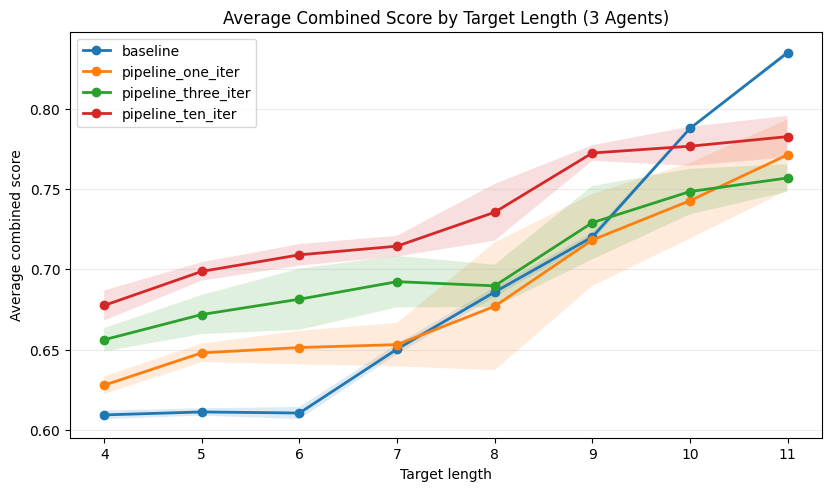

In [20]:
import matplotlib.pyplot as plt
import numpy as np

if "hardness_summary_df" not in globals() or hardness_summary_df.empty:
    print("Run the hard target-length experiment cell first to generate hardness_summary_df.")
else:
    plot_df = hardness_summary_df.copy()
    methods_order = ["baseline", "pipeline_one_iter", "pipeline_three_iter", "pipeline_ten_iter"]

    target_lengths = sorted(plot_df["target_length"].unique(), reverse=True)
    x = np.array(target_lengths, dtype=float)

    fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)

    for method_name in methods_order:
        part = plot_df[plot_df["method"] == method_name].set_index("target_length")
        means = np.array([float(part.loc[t, "avg_score"]) if t in part.index else np.nan for t in target_lengths], dtype=float)
        errs = np.array(
            [
                float(part.loc[t, "std_score"]) if (t in part.index and pd.notna(part.loc[t, "std_score"])) else 0.0
                for t in target_lengths
            ],
            dtype=float,
        )

        ax.plot(x, means, marker="o", linewidth=2.0, label=method_name)
        ax.fill_between(x, means - errs, means + errs, alpha=0.15)

    ax.set_title("Average Combined Score by Target Length (3 Agents)")
    ax.set_xlabel("Target length")
    ax.set_ylabel("Average combined score")
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in x])
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.show()

## Variety Study

Uses results from the previous cell.
Metrics: generated_mean, unique_mean, duplicate_mean, duplicate_rate_mean.

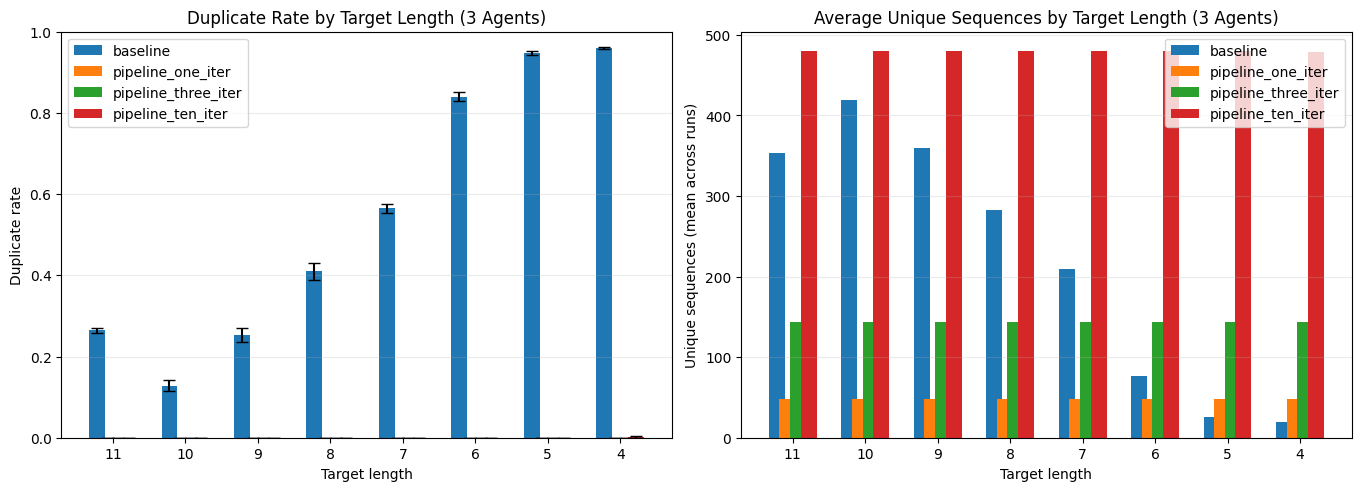

,target_length,method,requested_budget_mean,generated_mean,unique_mean,duplicate_mean,duplicate_rate_mean,duplicate_rate_std,topk_generated_mean,topk_unique_mean,topk_duplicate_mean,topk_duplicate_rate_mean,topk_duplicate_rate_std
0,11,baseline,480.0,480.0,353.2,126.8,0.264167,0.005187,480.0,353.2,126.8,0.264167,0.005187
1,11,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,4.0,4.0,0.0,0.000000,0.000000
2,11,pipeline_ten_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
3,11,pipeline_three_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,9.0,9.0,0.0,0.000000,0.000000
4,10,baseline,480.0,480.0,418.6,61.4,0.127917,0.013307,480.0,418.6,61.4,0.127917,0.013307
5,10,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,2.8,2.8,0.0,0.000000,0.000000
6,10,pipeline_ten_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
7,10,pipeline_three_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,8.6,8.6,0.0,0.000000,0.000000
8,9,baseline,480.0,480.0,359.0,121.0,0.252083,0.017180,480.0,359.0,121.0,0.252083,0.017180
9,9,pipeline_one_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,4.8,4.8,0.0,0.000000,0.000000


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "hardness_variety_summary_df" not in globals() or hardness_variety_summary_df.empty:
    print("Run the hard target-length experiment cell first to generate hardness_variety_summary_df.")
else:
    variety_plot_df = hardness_variety_summary_df.copy()
    methods_order = ["baseline", "pipeline_one_iter", "pipeline_three_iter", "pipeline_ten_iter"]

    target_lengths = sorted(variety_plot_df["target_length"].unique(), reverse=True)
    labels = [str(int(v)) for v in target_lengths]
    x = np.arange(len(labels))

    width = 0.22
    offsets = np.linspace(-width, width, len(methods_order))

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True)

    for method_name, dx in zip(methods_order, offsets):
        part = variety_plot_df[variety_plot_df["method"] == method_name].set_index("target_length")

        dup_rate = np.array(
            [float(part.loc[t, "duplicate_rate_mean"]) if t in part.index else 0.0 for t in target_lengths],
            dtype=float,
        )
        dup_err = np.array(
            [
                float(part.loc[t, "duplicate_rate_std"])
                if (t in part.index and pd.notna(part.loc[t, "duplicate_rate_std"]))
                else 0.0
                for t in target_lengths
            ],
            dtype=float,
        )
        unique_vals = np.array(
            [float(part.loc[t, "unique_mean"]) if t in part.index else 0.0 for t in target_lengths],
            dtype=float,
        )

        axes[0].bar(
            x + dx,
            dup_rate,
            width,
            yerr=dup_err,
            capsize=4,
            label=method_name,
        )

        axes[1].bar(
            x + dx,
            unique_vals,
            width,
            label=method_name,
        )

    axes[0].set_title("Duplicate Rate by Target Length (3 Agents)")
    axes[0].set_xlabel("Target length")
    axes[0].set_ylabel("Duplicate rate")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend()

    axes[1].set_title("Average Unique Sequences by Target Length (3 Agents)")
    axes[1].set_xlabel("Target length")
    axes[1].set_ylabel("Unique sequences (mean across runs)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend()

    plt.show()

    method_variety_df = (
        variety_plot_df[
            [
                "target_length",
                "method",
                "requested_budget_mean",
                "generated_mean",
                "unique_mean",
                "duplicate_mean",
                "duplicate_rate_mean",
                "duplicate_rate_std",
                "topk_generated_mean",
                "topk_unique_mean",
                "topk_duplicate_mean",
                "topk_duplicate_rate_mean",
                "topk_duplicate_rate_std",
            ]
        ]
        .sort_values(["target_length", "method"], ascending=[False, True])
        .reset_index(drop=True)
    )
    display(method_variety_df)

In [12]:
import gc
gc.collect()
if "torch" in globals() and torch.cuda.is_available():
    torch.cuda.empty_cache()